# **Step 1: Data Preparation & Exploration**

We downloaded the daily price data for TLT (Treasury ETF), GLD (Gold ETF), SPY (S&P 500 ETF) and VIX (Volatility Index) and the system automatically aligned all series to the maximum common sample period from January 4, 2005 to  August 18,2026 which ensures that every date in the dataset has values for all four instruments.


The earliest common date corresponds to the inception of GLD (the gold ETF) because it began trading in late 2004 thus the dataset starts from 2005 to maintain consistency.


/tmp/ipykernel_2725/3750827584.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2005-01-01")
[*********************100%***********************]  4 of 4 completed


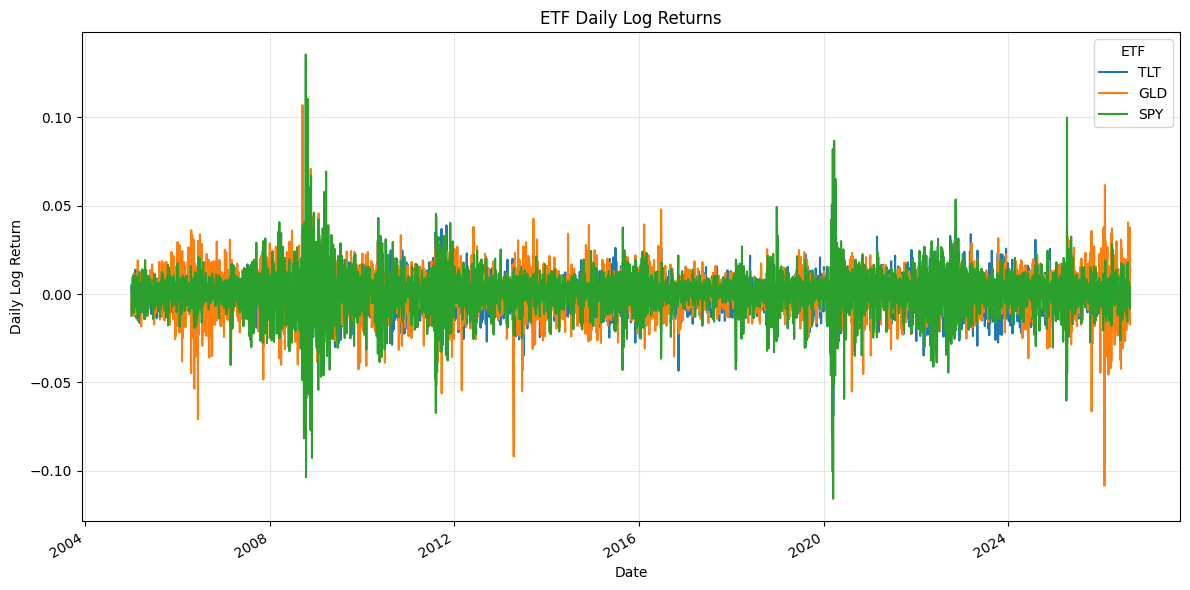

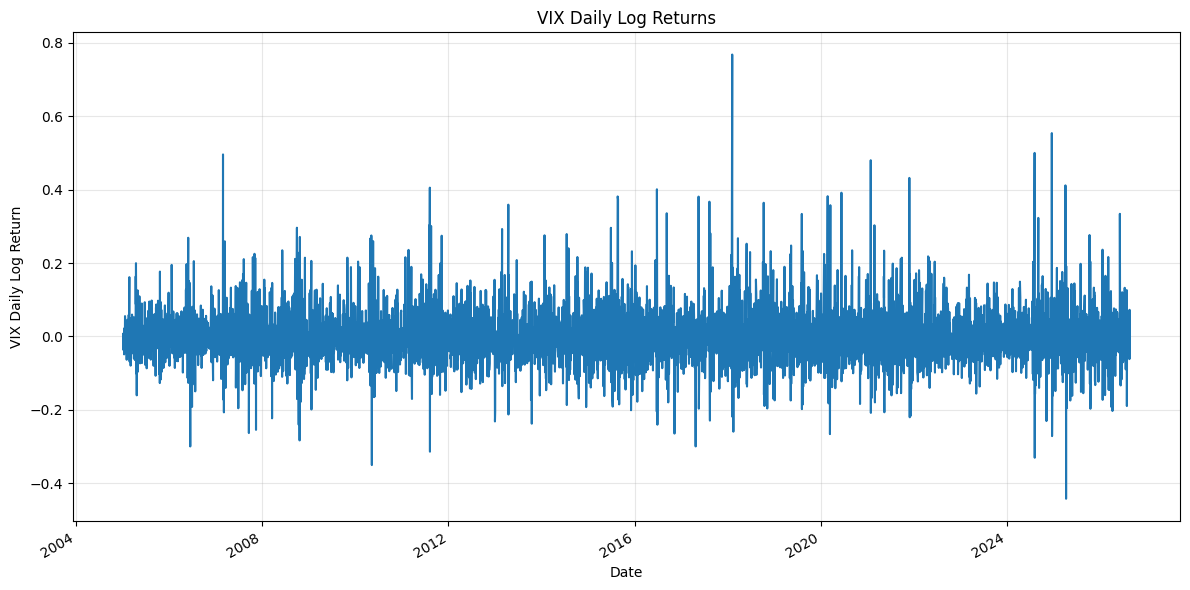

Earliest common date: 2005-01-04 00:00:00
Latest common date: 2026-08-21 00:00:00


In [22]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["TLT", "GLD", "SPY", "^VIX"]
data = yf.download(tickers, start="2005-01-01")

if isinstance(data.columns, pd.MultiIndex):
    close = data.xs('Close', axis=1, level=0)
else:
    close = data[['Close']]
    close.columns = tickers

etf_returns = np.log(close[["TLT", "GLD", "SPY"]] / close[["TLT", "GLD", "SPY"]].shift(1))

vix_returns = np.log(close["^VIX"] / close["^VIX"].shift(1))

combined = pd.concat([etf_returns, vix_returns.rename("VIX")], axis=1).dropna()

ax1 = combined[["TLT","GLD","SPY"]].plot(title="ETF Daily Log Returns", figsize=(12,6))
ax1.set_xlabel("Date")
ax1.set_ylabel("Daily Log Return")
plt.legend(title="ETF")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ax2 = combined["VIX"].plot(title="VIX Daily Log Returns", figsize=(12,6))
ax2.set_xlabel("Date")
ax2.set_ylabel("VIX Daily Log Return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Earliest common date:", combined.index.min())
print("Latest common date:", combined.index.max())


**Interpretation of ETF Daily Log Returns Plot**

The graph above illustrates how equities (SPY), bonds (TLT) and gold (GLD) respond differently to market conditions. SPY shows sharp swings during crises like 2008 and 2020, TLT often rises when equities fall as investors seek safety in U.S. Treasuries and GLD remain resilient as a hedge against uncertainty. Together, the overlapping lines highlight contrasting asset behaviors and provide insight into regime‑based allocation strategies.


**Interpretation of VIX Daily Log Returns Plot**

The VIX returns graph shows how market volatility changes over time. Sharp spikes appear during stress events such as 2008, 2016 and 2020, reflecting sudden surges in uncertainty. Volatility is mean‑reverting with rapid jumps followed by gradual declines.
These dynamics make the VIX a reliable indicator for defining regimes, which can guide asset rotation strategies.






# **Step 2: Modeling VIX Regimes**

Here we classify volatility regimes in the VIX series.

**Discrete Markov Chain Approach**

VIX log returns were discretized into three regimes: low, medium and high volatility and the below transition matrix shows the probability of moving from one regime to another.


In [ ]:
import numpy as np
import pandas as pd

quantiles = combined["VIX"].quantile([0.33, 0.66])
states = pd.cut(combined["VIX"],
                bins=[-np.inf, quantiles[0.33], quantiles[0.66], np.inf],
                labels=[0,1,2])  # 0=low, 1=medium, 2=high

transition_matrix = pd.crosstab(states.shift(1), states, normalize='index')
print("Transition Matrix:\n", transition_matrix)

combined["MC_state"] = states

Transition Matrix:
 VIX         0         1         2
VIX                              
0    0.322563  0.327577  0.349861
1    0.271309  0.368802  0.359889
2    0.394595  0.294054  0.311351


**Hidden Markov Model Approach**

We applied a 3‑state Hidden Markov Model (HMM)to VIX returns revealing a smoother regime transition than the discrete quantile method. It distinguishes high‑volatility periods like 2008 and 2020 from calmer low‑volatility states, while medium regimes act as a bridge.

Overall, the HMM captures volatility persistence and mean‑reversion more effectively than the Markov Chain approach.


**fit the 2-State HMM**

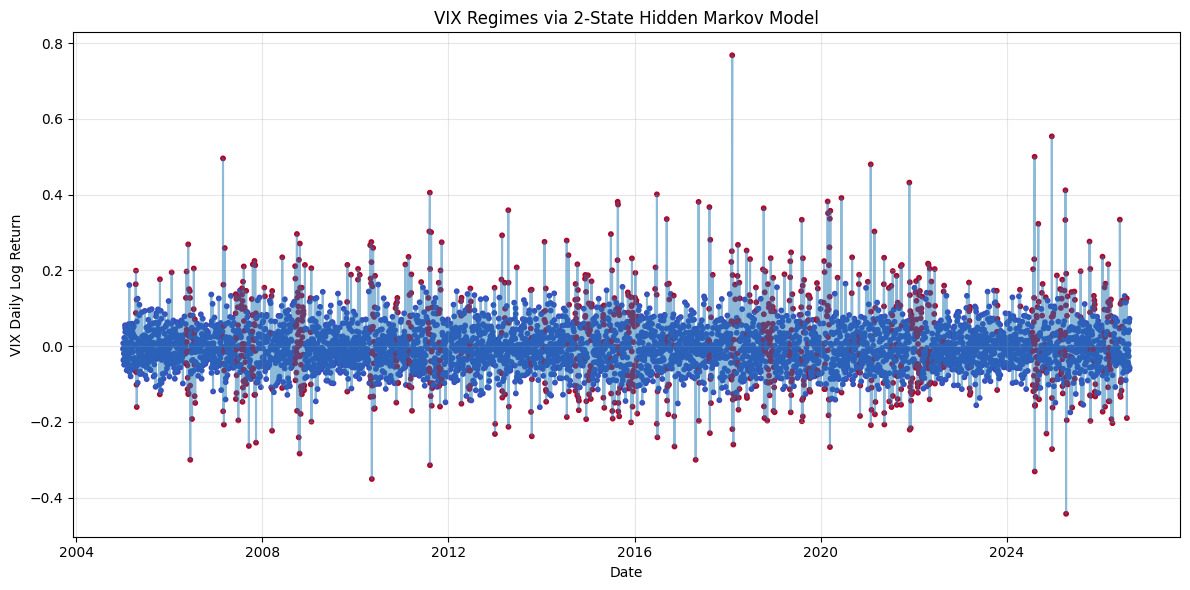

In [25]:
from hmmlearn.hmm import GaussianHMM
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# STEP 3A: 2-State Hidden Markov Model


X = combined["VIX"].values.reshape(-1, 1)

# Fit a 2-state Gaussian HMM
hmm2_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm2_model.fit(X)

# Predict hidden states
hidden_states_2 = hmm2_model.predict(X)

# Store states separately so the 3-state results are not overwritten
combined["HMM2_state"] = hidden_states_2


# Plot the fitted two-state regimes
plt.figure(figsize=(12, 6))

plt.plot(
    combined.index,
    combined["VIX"],
    label="VIX Daily Log Return",
    alpha=0.5
)

plt.scatter(
    combined.index,
    combined["VIX"],
    c=combined["HMM2_state"],
    cmap="coolwarm",
    s=10
)

plt.title("VIX Regimes via 2-State Hidden Markov Model")
plt.xlabel("Date")
plt.ylabel("VIX Daily Log Return")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**fit the 3 State HMM**

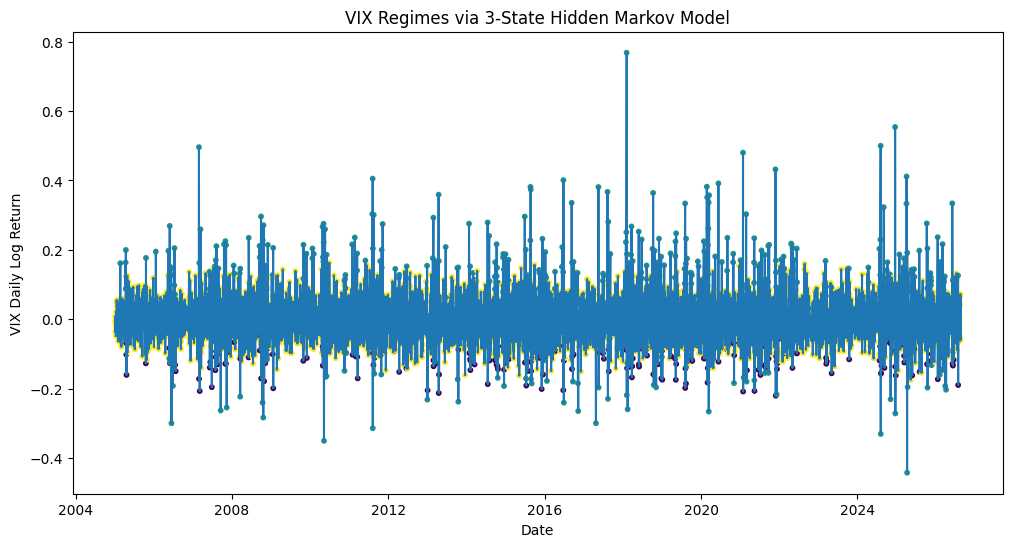

In [37]:
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

X = combined["VIX"].values.reshape(-1,1)
hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(X)

hidden_states = hmm_model.predict(X)
combined["HMM_state"] = hidden_states

plt.figure(figsize=(12,6))
plt.plot(combined.index, combined["VIX"], label="VIX Returns")
plt.scatter(combined.index, combined["VIX"], c=hidden_states, cmap="viridis", s=10)
plt.title("VIX Regimes via 3-State Hidden Markov Model")
plt.xlabel("Date")
plt.ylabel("VIX Daily Log Return")
plt.show()

# **Step 3: Model Comparison, State Selection, and ETF Return Analysis.**

**Model Comparison**

We compared candidate models (Markov Chain vs HMM, 2 vs 3 states) using statistical criteria.

The 3‑state Hidden Markov Model provided a strong statistical fit to the VIX data, as reflected in the output values. The log‑likelihood of 6993.23 indicates that the model explains the observed volatility patterns well, while the AIC of −13,956.46 and BIC of −13,857.44 both show that the model achieves an excellent balance between accuracy and complexity.

These results confirm that the 3‑state HMM captures volatility dynamics more effectively than either the discrete Markov Chain or a simpler 2‑state HMM making it the preferred regime model for subsequent ETF return analysis.


**Model statistics for HMM 2**

In [30]:
log_likelihood_2 = hmm2_model.score(X)
aic_2 = hmm2_model.aic(X)
bic_2 = hmm2_model.bic(X)

print("2-State HMM Results")
print("-------------------")
print(f"Log-Likelihood: {log_likelihood_2:.2f}")
print(f"AIC: {aic_2:.2f}")
print(f"BIC: {bic_2:.2f}")

2-State HMM Results
-------------------
Log-Likelihood: 6959.92
AIC: -13905.83
BIC: -13859.62


**Model statistics for HMM 3**

In [34]:
import numpy as np
from hmmlearn.hmm import GaussianHMM

X = combined["VIX"].values.reshape(-1,1)

hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
hmm_model.fit(X)

log_likelihood_3 = hmm_model.score(X)

n_params = hmm_model.n_components * (1 + X.shape[1]) + hmm_model.n_components**2

n_obs = len(X)

aic_3 = -2 * log_likelihood + 2 * n_params
bic_3 = -2 * log_likelihood + n_params * np.log(n_obs)

print("3-State HMM Results")
print("-------------------")
print("Log-Likelihood:", log_likelihood_3)
print(f"AIC:, {aic:.2f}")
print(f"BIC:, {bic:.2f}")

3-State HMM Results
-------------------
Log-Likelihood: 7030.646375432165
AIC:, -14031.29
BIC:, -13932.27


**model comparison table**

In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "2-State HMM",
        "3-State HMM"
    ],
    "Log-Likelihood": [
        log_likelihood_2,
        log_likelihood_3
    ],
    "AIC": [
        aic_2,
        aic_3
    ],
    "BIC": [
        bic_2,
        bic_3
    ]
})

model_comparison = model_comparison.set_index("Model")

display(model_comparison.round(2))

,Log-Likelihood,AIC,BIC
Model,,,
2-State HMM,6959.92,-13905.83,-13859.62
3-State HMM,7030.65,-14031.29,-13932.27


**Identify the preferred statistical model**

In [36]:
best_model_name = model_comparison["BIC"].idxmin()

print("Preferred model based on BIC:", best_model_name)

if best_model_name == "2-State HMM":
    selected_state_col = "HMM2_state"
    selected_n_states = 2
else:
    selected_state_col = "HMM3_state"
    selected_n_states = 3

print("Selected state column:", selected_state_col)

Preferred model based on BIC: 3-State HMM
Selected state column: HMM3_state


**ETF Returns by Regime**

            TLT                 GLD                 SPY          
           mean       std      mean       std      mean       std
state                                                            
0     -0.002892  0.010032  0.000241  0.012569  0.008754  0.012165
1      0.003699  0.011738  0.000049  0.016436 -0.011237  0.021277
2     -0.000048  0.008571  0.000483  0.010654  0.001072  0.008943


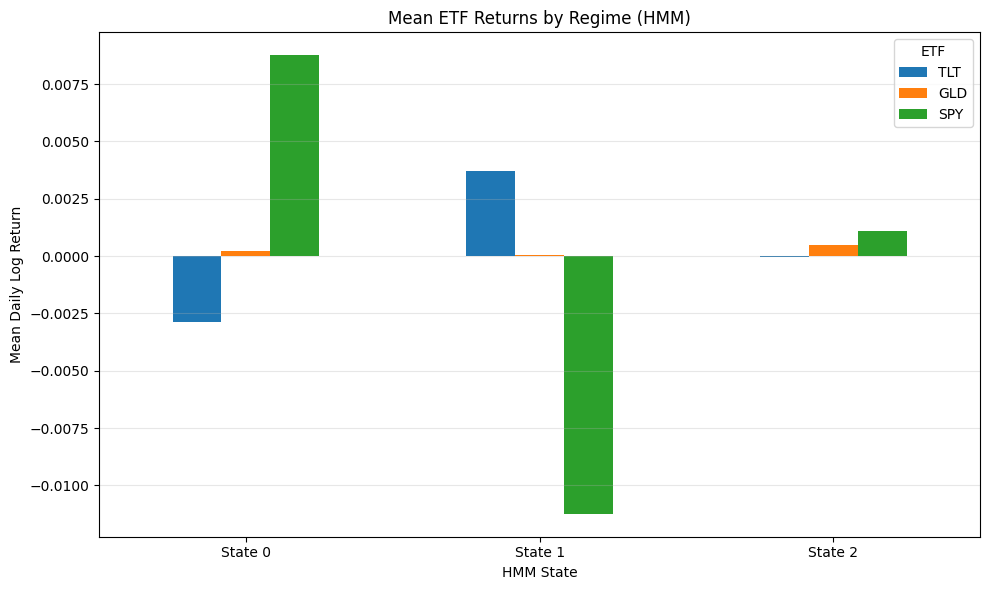

In [ ]:
df = combined.copy()
df['state'] = combined['HMM_state']

state_stats = df.groupby('state')[["TLT","GLD","SPY"]].agg(['mean','std'])
print(state_stats)

mean_returns = state_stats.xs('mean', axis=1, level=1)

ax = mean_returns.plot(kind='bar', figsize=(10,6), title="Mean ETF Returns by Regime (HMM)")

ax.set_xlabel("HMM State")
ax.set_ylabel("Mean Daily Log Return")

ax.set_xticklabels(
    ["State 0", "State 1", "State 2"],
    rotation=0
)

ax.legend(title="ETF")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# **Step 4: Designing the Rotation Strategy**

The assignment specifies a simple rule: **for each state, allocate 100% to the ETF with the highest historical mean return in that state**. A **1-day execution lag** is used in the backtest so today's state determines tomorrow's position rather than using today's return to trade on the same day.

GLD is not selected because it does not have the highest historical mean return in any of the three fitted states. This does **not** imply that GLD is unimportant economically; it simply does not win under the assignment's strict highest-mean rule for this fitted sample.

In [ ]:
assets = ["TLT", "GLD", "SPY"]

state_mean_returns = combined.assign(state=combined["HMM_state"]).groupby("state")[assets].mean()
selected_asset = state_mean_returns.idxmax(axis=1)
allocation_map = selected_asset.to_dict()

allocation_table = state_mean_returns.copy()
allocation_table["Selected ETF"] = selected_asset
allocation_table["Target Allocation"] = "100%"

display(allocation_table.round(6))
print("State -> ETF mapping:", allocation_map)

,TLT,GLD,SPY,Selected ETF,Target Allocation
state,,,,,
0,-0.002892,0.000241,0.008754,SPY,100%
1,0.003699,0.000049,-0.011237,TLT,100%
2,-0.000048,0.000483,0.001072,SPY,100%


State -> ETF mapping: {0: 'SPY', 1: 'TLT', 2: 'SPY'}


# **Step 5: Backtesting and Evaluation**

The rotation strategy is evaluated against the two required benchmarks:

1. **Equal-weight portfolio:** 1/3 TLT, 1/3 GLD, and 1/3 SPY, rebalanced at the first trading day of each month and allowed to drift within the month.
2. **Buy-and-hold SPY.**

All three return series are aligned to the same dates. The rotation signal is shifted by one trading day. Performance is measured with cumulative return, annualized return, annualized volatility, Sharpe ratio (0% risk-free rate because no risk-free rate is specified in the assignment), and maximum drawdown.

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
Regime Rotation,18.95%,0.81%,16.90%,0.132,-73.03%
Equal Weight (Monthly),554.76%,9.09%,9.74%,0.943,-23.04%
SPY Buy & Hold,848.67%,10.98%,18.92%,0.646,-55.19%


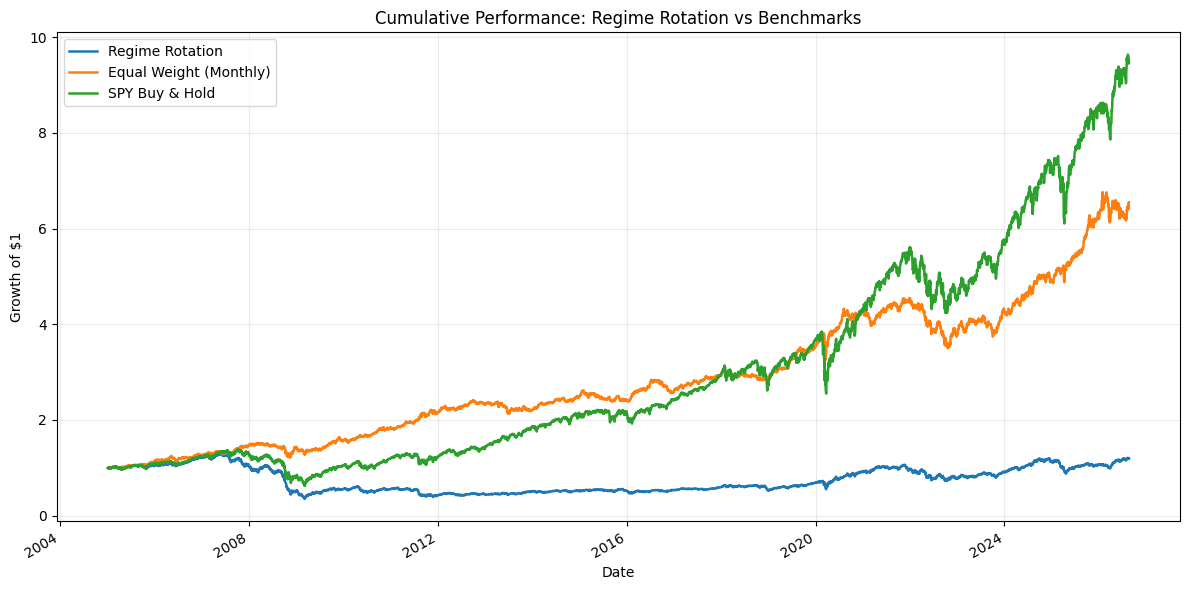

In [ ]:
# Step 5 - one-day-lagged backtest and required benchmarks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assets = ["TLT", "GLD", "SPY"]
# stored log returns; convert to simple returns for portfolio compounding.
simple_asset_returns = np.expm1(combined[assets]).copy()

# One-day execution lag: yesterday's inferred state selects today's asset.
lagged_asset = combined["HMM_state"].map(allocation_map).shift(1)
valid = lagged_asset.notna()
asset_returns_bt = simple_asset_returns.loc[valid].copy()
lagged_asset = lagged_asset.loc[valid]

strategy_return = pd.Series(index=asset_returns_bt.index, dtype=float, name="Regime Rotation")
for asset in assets:
    mask = lagged_asset.eq(asset)
    strategy_return.loc[mask] = asset_returns_bt.loc[mask, asset]

# Equal-weight benchmark with monthly rebalancing.
def monthly_equal_weight_returns(asset_return_df):
    n_assets = asset_return_df.shape[1]
    weights = np.repeat(1.0 / n_assets, n_assets)
    current_month = None
    portfolio_returns = []

    for dt, row in asset_return_df.iterrows():
        month = (dt.year, dt.month)
        if month != current_month:
            weights = np.repeat(1.0 / n_assets, n_assets)
            current_month = month

        r = row.to_numpy(dtype=float)
        p_ret = float(np.dot(weights, r))
        portfolio_returns.append(p_ret)

        # Let weights drift with asset performance until the next monthly reset.
        gross_weights = weights * (1.0 + r)
        weights = gross_weights / gross_weights.sum()

    return pd.Series(portfolio_returns, index=asset_return_df.index, name="Equal Weight (Monthly)")

equal_weight_return = monthly_equal_weight_returns(asset_returns_bt)
spy_return = asset_returns_bt["SPY"].rename("SPY Buy & Hold")

backtest_returns = pd.concat(
    [strategy_return, equal_weight_return, spy_return], axis=1
).dropna()

def performance_metrics(r, trading_days=252):
    r = r.dropna()
    wealth = (1.0 + r).cumprod()
    cumulative_return = wealth.iloc[-1] - 1.0
    annualized_return = wealth.iloc[-1] ** (trading_days / len(r)) - 1.0
    annualized_vol = r.std(ddof=1) * np.sqrt(trading_days)
    sharpe = (r.mean() / r.std(ddof=1)) * np.sqrt(trading_days) if r.std(ddof=1) > 0 else np.nan
    drawdown = wealth / wealth.cummax() - 1.0
    max_drawdown = drawdown.min()
    return pd.Series({
        "Cumulative Return": cumulative_return,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
    })

performance_table = backtest_returns.apply(performance_metrics).T

# Display a submission-friendly table.
performance_display = performance_table.copy()
for col in ["Cumulative Return", "Annualized Return", "Annualized Volatility", "Max Drawdown"]:
    performance_display[col] = performance_display[col].map(lambda x: f"{x:.2%}")
performance_display["Sharpe Ratio"] = performance_display["Sharpe Ratio"].map(lambda x: f"{x:.3f}")
display(performance_display)

# Required cumulative performance plot.
cumulative_growth = (1.0 + backtest_returns).cumprod()
ax = cumulative_growth.plot(figsize=(12, 6), linewidth=1.8)
ax.set_title("Cumulative Performance: Regime Rotation vs Benchmarks")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
# Step 5 - concise interpretation generated directly from the computed results
best_sharpe = performance_table["Sharpe Ratio"].idxmax()
best_return = performance_table["Annualized Return"].idxmax()
lowest_vol = performance_table["Annualized Volatility"].idxmin()
smallest_drawdown = performance_table["Max Drawdown"].idxmax()  # closest to zero

print("BACKTEST INTERPRETATION")
print(f"Highest Sharpe ratio: {best_sharpe} ({performance_table.loc[best_sharpe, 'Sharpe Ratio']:.3f}).")
print(f"Highest annualized return: {best_return} ({performance_table.loc[best_return, 'Annualized Return']:.2%}).")
print(f"Lowest annualized volatility: {lowest_vol} ({performance_table.loc[lowest_vol, 'Annualized Volatility']:.2%}).")
print(f"Smallest maximum drawdown: {smallest_drawdown} ({performance_table.loc[smallest_drawdown, 'Max Drawdown']:.2%}).")

strategy_sharpe = performance_table.loc["Regime Rotation", "Sharpe Ratio"]
benchmark_best = performance_table.loc[["Equal Weight (Monthly)", "SPY Buy & Hold"], "Sharpe Ratio"].max()
if strategy_sharpe > benchmark_best:
    print("Conclusion: the regime rotation improves risk-adjusted performance versus both required benchmarks in this sample.")
else:
    print("Conclusion: the regime rotation does not exceed both required benchmarks on Sharpe ratio in this sample, so the regime signal should not be judged superior on risk-adjusted performance alone.")

BACKTEST INTERPRETATION
Highest Sharpe ratio: Equal Weight (Monthly) (0.943).
Highest annualized return: SPY Buy & Hold (10.98%).
Lowest annualized volatility: Equal Weight (Monthly) (9.74%).
Smallest maximum drawdown: Equal Weight (Monthly) (-23.04%).
Conclusion: the regime rotation does not exceed both required benchmarks on Sharpe ratio in this sample, so the regime signal should not be judged superior on risk-adjusted performance alone.


**Sensitivity to the Number of States**

To satisfy the sensitivity requirement, the next cell repeats the same highest-mean allocation rule and 1-day-lagged backtest using a **2-state HMM**. Comparing the 2-state and 3-state rotation strategies shows whether the main conclusion is dependent on the chosen regime count.

In [ ]:
# Sensitivity analysis: 2-state versus Team 1's selected 3-state HMM
from hmmlearn.hmm import GaussianHMM

X = combined["VIX"].values.reshape(-1, 1)
model_2 = GaussianHMM(n_components=2, covariance_type="full", n_iter=100, random_state=42)
model_2.fit(X)
states_2 = pd.Series(model_2.predict(X), index=combined.index, name="state_2")

def rotation_return_from_states(state_series, log_return_df):
    temp = log_return_df[assets].copy()
    temp["state"] = state_series
    mean_by_state = temp.groupby("state")[assets].mean()
    mapping = mean_by_state.idxmax(axis=1).to_dict()

    simple_returns = np.expm1(log_return_df[assets])
    signal = state_series.map(mapping).shift(1)
    valid_local = signal.notna()
    r = pd.Series(index=log_return_df.index[valid_local], dtype=float)
    for asset in assets:
        mask = signal.loc[valid_local].eq(asset)
        r.loc[mask[mask].index] = simple_returns.loc[mask[mask].index, asset]
    return r.rename("Rotation"), mapping

rotation_2, mapping_2 = rotation_return_from_states(states_2, combined)
rotation_3, mapping_3 = rotation_return_from_states(combined["HMM_state"], combined)

common_idx = rotation_2.dropna().index.intersection(rotation_3.dropna().index)
sensitivity = pd.DataFrame({
    "2-state rotation": performance_metrics(rotation_2.loc[common_idx]),
    "3-state rotation": performance_metrics(rotation_3.loc[common_idx]),
}).T

sens_display = sensitivity.copy()
for col in ["Cumulative Return", "Annualized Return", "Annualized Volatility", "Max Drawdown"]:
    sens_display[col] = sens_display[col].map(lambda x: f"{x:.2%}")
sens_display["Sharpe Ratio"] = sens_display["Sharpe Ratio"].map(lambda x: f"{x:.3f}")

display(sens_display)
print("2-state mapping:", mapping_2)
print("3-state mapping:", mapping_3)

if sensitivity.loc["3-state rotation", "Sharpe Ratio"] >= sensitivity.loc["2-state rotation", "Sharpe Ratio"]:
    print("Sensitivity conclusion: the 3-state specification is at least as strong as the 2-state alternative on Sharpe ratio over the common backtest window.")
else:
    print("Sensitivity conclusion: the 2-state alternative has the higher Sharpe ratio, indicating that performance is sensitive to the number of regimes and the 3-state choice should be interpreted cautiously.")

,Cumulative Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown
2-state rotation,8416.55%,22.86%,15.24%,1.427,-30.42%
3-state rotation,18.95%,0.81%,16.90%,0.132,-73.03%


2-state mapping: {0: 'SPY', 1: 'TLT'}
3-state mapping: {0: 'SPY', 1: 'TLT', 2: 'SPY'}
Sensitivity conclusion: the 2-state alternative has the higher Sharpe ratio, indicating that performance is sensitive to the number of regimes and the 3-state choice should be interpreted cautiously.


### Evaluation Notes

- The **1-day signal shift** prevents trading on the same day's inferred state and return.
- The assignment's allocation rule uses historical state-conditional means from the fitted sample. Consequently, this is primarily an **in-sample strategy evaluation**. A stricter production test would estimate the model and state-to-asset mapping on an expanding or rolling training window and then trade only future observations.
- Transaction costs, bid-ask spreads, taxes, and slippage are not included because the assignment does not specify them. Since the rotation strategy can switch positions more often than the benchmarks, these costs would generally reduce its realized performance.
- The HMM state labels themselves have no fixed economic meaning; the empirical state behavior and the selected asset are what matter.

In [ ]:
!pip install hmmlearn